In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_d")

# Ruta
RUTA = "/Users/lucasespinosa/Documents/store-sales-time-series-forecasting/"

# Carga de archivos
train        = pd.read_csv(RUTA + "train.csv",           parse_dates=["date"])
stores       = pd.read_csv(RUTA + "stores.csv")
oil          = pd.read_csv(RUTA + "oil.csv",             parse_dates=["date"])
holidays     = pd.read_csv(RUTA + "holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(RUTA + "transactions.csv",    parse_dates=["date"])

print("✅ Archivos cargados")
print(f"train:        {train.shape[0]:,} filas")
print(f"stores:       {stores.shape[0]:,} filas")
print(f"oil:          {oil.shape[0]:,} filas")
print(f"holidays:     {holidays.shape[0]:,} filas")
print(f"transactions: {transactions.shape[0]:,} filas")

✅ Archivos cargados
train:        3,000,888 filas
stores:       54 filas
oil:          1,218 filas
holidays:     350 filas
transactions: 83,488 filas


In [2]:
# ── BLOQUE 2 — Aplicar foco: 6 familias top + tiendas de Quito ──

FAMILIAS = ["GROCERY I", "BEVERAGES", "PRODUCE", "CLEANING", "DAIRY", "BREAD/BAKERY"]
tiendas_quito = stores[stores["city"] == "Quito"]["store_nbr"].tolist()

df = train[
    (train["family"].isin(FAMILIAS)) &
    (train["store_nbr"].isin(tiendas_quito))
].copy()

print(f"Tiendas de Quito: {sorted(tiendas_quito)}")
print(f"Filas tras el foco: {df.shape[0]:,}")
print(f"Series temporales (tienda × familia): {df['store_nbr'].nunique() * df['family'].nunique()}")
print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
print("✅ Foco aplicado")

Tiendas de Quito: [1, 2, 3, 4, 6, 7, 8, 9, 10, 17, 18, 20, 44, 45, 46, 47, 48, 49]
Filas tras el foco: 181,872
Series temporales (tienda × familia): 108
Período: 2013-01-01 → 2017-08-15
✅ Foco aplicado


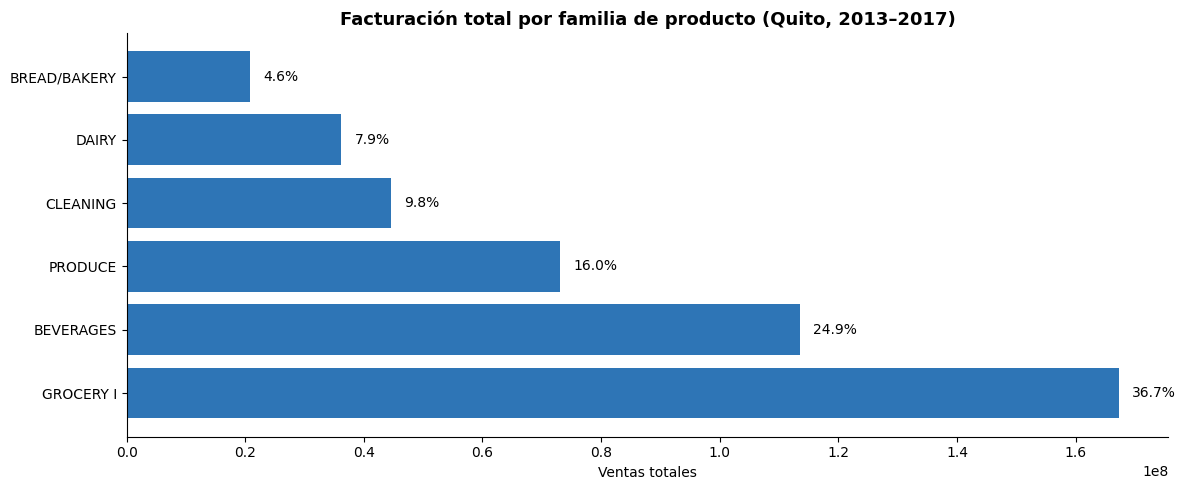

✅ Gráfico 1 guardado


In [3]:
# ── BLOQUE 3 — Ventas totales por familia ──

ventas_familia = df.groupby("family")["sales"].sum().sort_values(ascending=False)
total = ventas_familia.sum()
pct = (ventas_familia / total * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ventas_familia.index, ventas_familia.values, color="#2E75B6")
ax.set_xlabel("Ventas totales")
ax.set_title("Facturación total por familia de producto (Quito, 2013–2017)", 
             fontsize=13, fontweight="bold")

for i, (bar, p) in enumerate(zip(bars, pct.values)):
    ax.text(bar.get_width() + total*0.005, bar.get_y() + bar.get_height()/2,
            f"{p}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("grafico1_ventas_familia.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado")

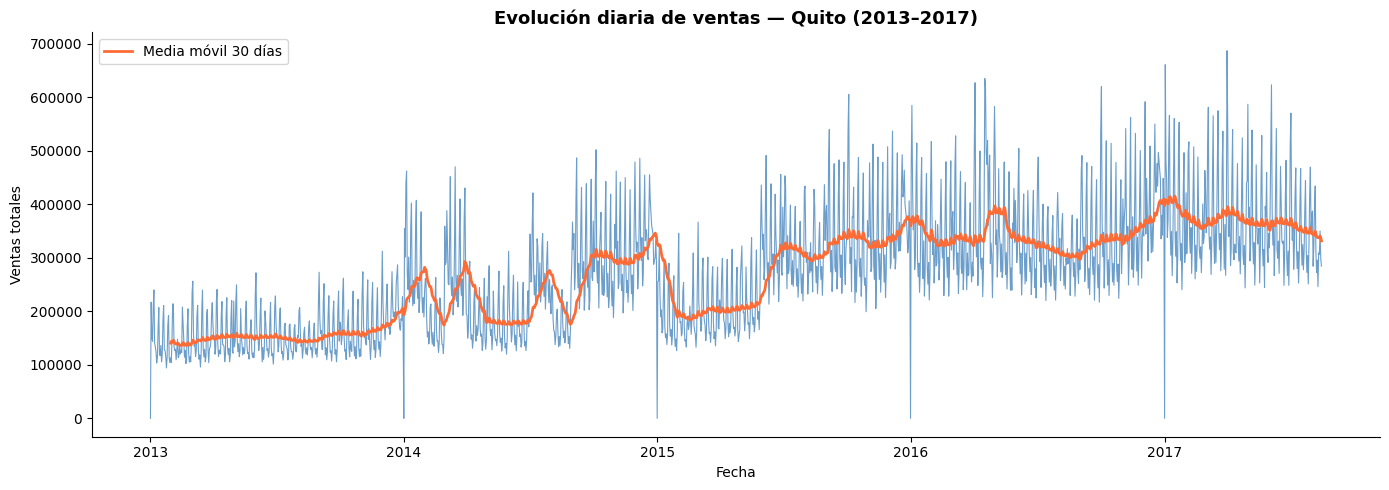

✅ Gráfico 2 guardado


In [4]:
# ── BLOQUE 4 — Evolución temporal de ventas ──

ventas_diarias = df.groupby("date")["sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ventas_diarias["date"], ventas_diarias["sales"], 
        color="#2E75B6", linewidth=0.8, alpha=0.7)

# Media móvil 30 días para ver la tendencia
ventas_diarias["mm30"] = ventas_diarias["sales"].rolling(30).mean()
ax.plot(ventas_diarias["date"], ventas_diarias["mm30"], 
        color="#FF6B35", linewidth=2, label="Media móvil 30 días")

ax.set_title("Evolución diaria de ventas — Quito (2013–2017)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas totales")
ax.legend()
plt.tight_layout()
plt.savefig("grafico2_evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 2 guardado")

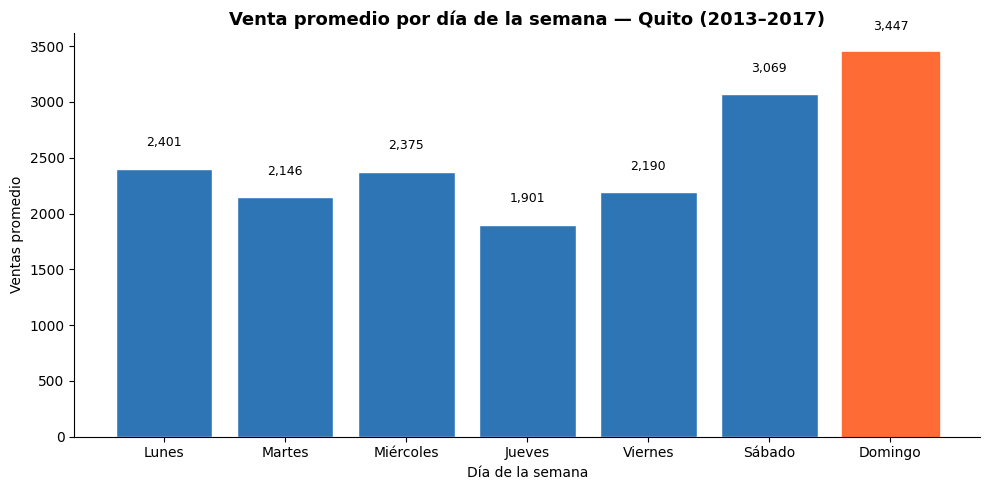

✅ Gráfico 3 guardado


In [5]:
# ── BLOQUE 5 — Estacionalidad semanal ──

df["dia_semana"] = df["date"].dt.dayofweek
df["nombre_dia"] = df["date"].dt.day_name()

orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
nombres_es = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

ventas_dia = df.groupby("nombre_dia")["sales"].mean().reindex(orden_dias)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nombres_es, ventas_dia.values, color="#2E75B6", edgecolor="white")

# Resaltar el día más alto
max_idx = ventas_dia.values.argmax()
bars[max_idx].set_color("#FF6B35")

ax.set_title("Venta promedio por día de la semana — Quito (2013–2017)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Ventas promedio")
ax.set_xlabel("Día de la semana")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{bar.get_height():,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("grafico3_estacionalidad_semanal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 3 guardado")

In [8]:
# ── BLOQUE 6 — Efecto promoción ──

df["onpromotion"] = df["onpromotion"].fillna(0).astype(int)

# Diagnóstico
promo = df.groupby("onpromotion")["sales"].mean().reset_index()
print(promo)
print(promo["onpromotion"].unique())
print(promo.dtypes)

     onpromotion         sales
0              0   1605.585134
1              1   2009.775778
2              2   2034.747748
3              3   2420.213523
4              4   2688.726430
..           ...           ...
248          248  12169.133000
249          249  12377.413000
250          250  12231.239000
251          251  10599.315667
252          252  11089.586000

[253 rows x 2 columns]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148

In [9]:
# ── BLOQUE 6 — Efecto promoción (versión correcta) ──

df["hay_promo"] = (df["onpromotion"] > 0).astype(int)

promo = df.groupby("hay_promo")["sales"].mean().reset_index()
labels = ["Sin promoción", "Con promoción"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, promo["sales"].values,
              color=["#2E75B6", "#FF6B35"], width=0.5, edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{bar.get_height():,.0f}", ha="center", font

SyntaxError: incomplete input (602047618.py, line 14)

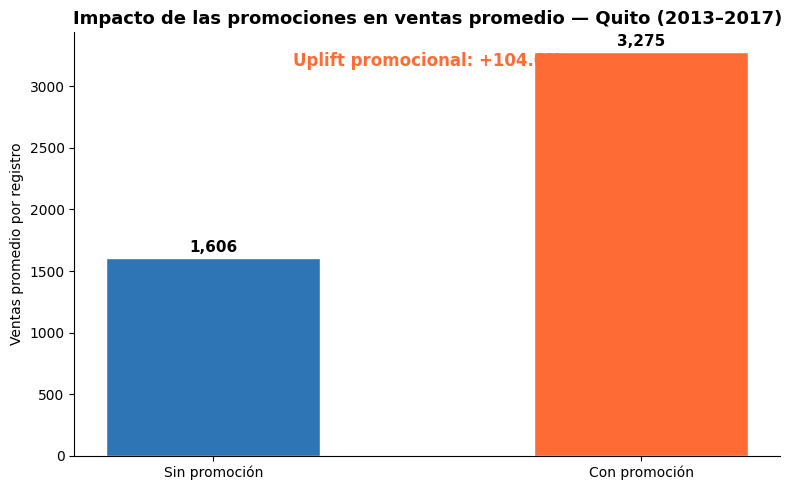

✅ Gráfico 4 guardado — Uplift: +104.0%


In [10]:
# ── BLOQUE 6 — Efecto promoción (versión correcta) ──

df["hay_promo"] = (df["onpromotion"] > 0).astype(int)
promo = df.groupby("hay_promo")["sales"].mean().reset_index()
labels = ["Sin promoción", "Con promoción"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, promo["sales"].values, color=["#2E75B6", "#FF6B35"], width=0.5, edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"{bar.get_height():,.0f}", ha="center", fontsize=11, fontweight="bold")

uplift = (promo[promo["hay_promo"]==1]["sales"].values[0] / promo[promo["hay_promo"]==0]["sales"].values[0] - 1) * 100

ax.set_title("Impacto de las promociones en ventas promedio — Quito (2013–2017)", fontsize=13, fontweight="bold")
ax.set_ylabel("Ventas promedio por registro")
ax.text(0.5, 0.92, f"Uplift promocional: +{uplift:.1f}%", transform=ax.transAxes, ha="center", fontsize=12, color="#FF6B35", fontweight="bold")

plt.tight_layout()
plt.savefig("grafico4_efecto_promocion.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico 4 guardado — Uplift: +{uplift:.1f}%")

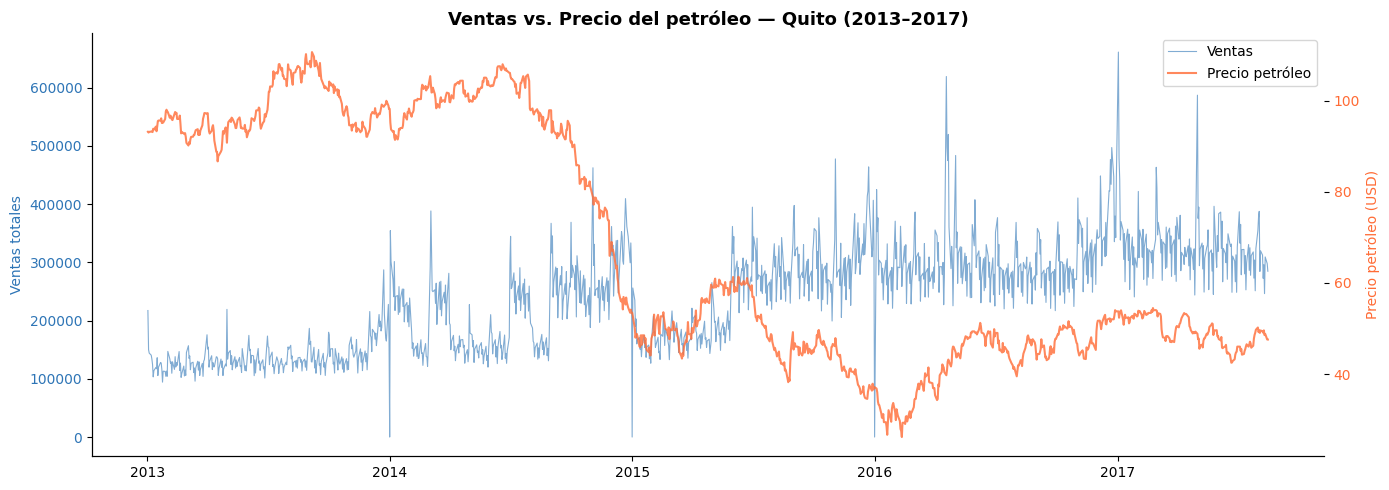

✅ Gráfico 5 guardado


In [11]:
# ── BLOQUE 7 — Efecto del precio del petróleo ──

# Unir oil con ventas diarias
ventas_diarias = df.groupby("date")["sales"].sum().reset_index()
oil_clean = oil.copy()
oil_clean["dcoilwtico"] = oil_clean["dcoilwtico"].ffill()  # rellenar días sin dato

merged = ventas_diarias.merge(oil_clean, on="date", how="left")
merged = merged.dropna(subset=["dcoilwtico"])

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(merged["date"], merged["sales"], color="#2E75B6", linewidth=0.8, alpha=0.6, label="Ventas")
ax1.set_ylabel("Ventas totales", color="#2E75B6")
ax1.tick_params(axis="y", labelcolor="#2E75B6")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["dcoilwtico"], color="#FF6B35", linewidth=1.5, alpha=0.8, label="Precio petróleo")
ax2.set_ylabel("Precio petróleo (USD)", color="#FF6B35")
ax2.tick_params(axis="y", labelcolor="#FF6B35")

ax1.set_title("Ventas vs. Precio del petróleo — Quito (2013–2017)", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig("grafico5_petroleo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 5 guardado")

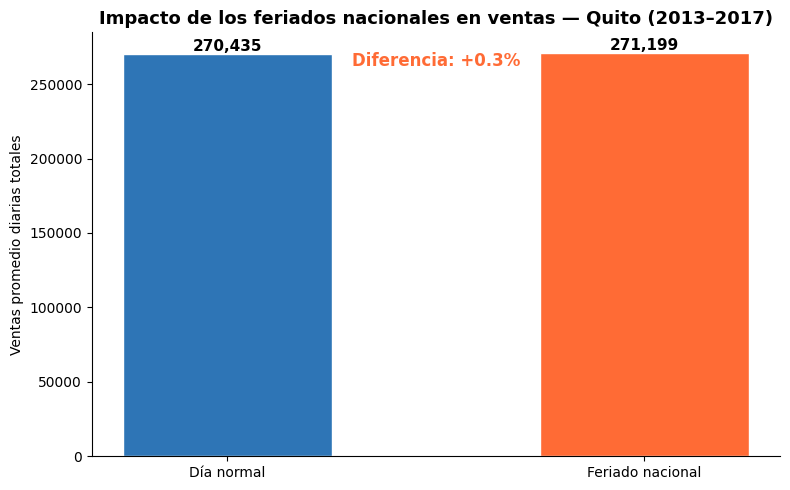

✅ Gráfico 6 guardado — Diferencia feriados: +0.3%


In [12]:
# ── BLOQUE 8 — Efecto de los feriados ──

holidays_nacional = holidays[
    (holidays["type"] == "Holiday") & 
    (holidays["locale"] == "National") &
    (holidays["transferred"] == False)
][["date"]].drop_duplicates()

holidays_nacional["es_feriado"] = 1

ventas_diarias = df.groupby("date")["sales"].sum().reset_index()
ventas_diarias = ventas_diarias.merge(holidays_nacional, on="date", how="left")
ventas_diarias["es_feriado"] = ventas_diarias["es_feriado"].fillna(0).astype(int)

feriado_efecto = ventas_diarias.groupby("es_feriado")["sales"].mean().reset_index()
labels = ["Día normal", "Feriado nacional"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, feriado_efecto["sales"].values, color=["#2E75B6", "#FF6B35"], width=0.5, edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, f"{bar.get_height():,.0f}", ha="center", fontsize=11, fontweight="bold")

diferencia = (feriado_efecto[feriado_efecto["es_feriado"]==1]["sales"].values[0] / feriado_efecto[feriado_efecto["es_feriado"]==0]["sales"].values[0] - 1) * 100

ax.set_title("Impacto de los feriados nacionales en ventas — Quito (2013–2017)", fontsize=13, fontweight="bold")
ax.set_ylabel("Ventas promedio diarias totales")
ax.text(0.5, 0.92, f"Diferencia: {diferencia:+.1f}%", transform=ax.transAxes, ha="center", fontsize=12, color="#FF6B35", fontweight="bold")

plt.tight_layout()
plt.savefig("grafico6_feriados.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico 6 guardado — Diferencia feriados: {diferencia:+.1f}%")